# GAMMA GLM (Generalized Linear Model)

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data_df = pd.read_csv("data_cleaned.csv")
print(f"Loaded {len(data_df)} rows, {len(data_df.columns)} columns")
print(f"Columns: {list(data_df.columns)}")
data_df.head()

Loaded 1328 rows, 9 columns
Columns: ['age', 'bmi', 'children', 'charges', 'gender_encoded', 'smoker_encoded', 'region_northwest', 'region_southeast', 'region_southwest']


,age,bmi,children,charges,gender_encoded,smoker_encoded,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,1,0.0,0.0,1.0
1,18,33.770,1,1725.55230,0,0,0.0,1.0,0.0
2,28,33.000,3,4449.46200,0,0,0.0,1.0,0.0
3,33,22.705,0,21984.47061,0,0,1.0,0.0,0.0
4,32,28.880,0,3866.85520,0,0,1.0,0.0,0.0


## 1. Data Splitting

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data_df['smoker_bmi'] = data_df['smoker_encoded'] * data_df['bmi']
data_df['age_squared'] = data_df['age'] ** 2

feature_cols = [
    'age', 'bmi', 'children', 'gender_encoded', 'smoker_encoded',
    'region_northwest', 'region_southeast', 'region_southwest',
    'smoker_bmi', 'age_squared'
]

X = data_df[feature_cols]
y = data_df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

Training set: 1062 samples
Test set:     266 samples


## 2. Model Training

In [45]:
from sklearn.linear_model import GammaRegressor
import numpy as np

model = GammaRegressor(alpha=1, max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

print("Gamma GLM model trained successfully.")
print(f"Intercept (log scale): {model.intercept_:.4f}")
print(f"Intercept (original scale): {np.exp(model.intercept_):,.2f}")

Gamma GLM model trained successfully.
Intercept (log scale): 9.2495
Intercept (original scale): 10,399.87


## 3. Model Evaluation (Gamma-first)

In [46]:
from sklearn.metrics import (
    mean_gamma_deviance,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

# Primary metric for Gamma GLM
gamma_dev_train = mean_gamma_deviance(y_train, y_pred_train)
gamma_dev_test = mean_gamma_deviance(y_test, y_pred_test)

# Secondary metrics (easy to interpret in original unit)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

# Optional metric
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

primary_secondary_metrics = pd.DataFrame({
    'Metric': ['Gamma Deviance', 'RMSE', 'MAE'],
    'Train': [gamma_dev_train, rmse_train, mae_train],
    'Test': [gamma_dev_test, rmse_test, mae_test]
})

optional_metrics = pd.DataFrame({
    'Metric (Optional)': ['R2'],
    'Train': [r2_train],
    'Test': [r2_test]
})

print('Primary + Secondary Metrics (recommended):\n')
print(primary_secondary_metrics.to_string(index=False, formatters={'Train': '{:,.4f}'.format, 'Test': '{:,.4f}'.format}))

print('\nOptional metric:\n')
print(optional_metrics.to_string(index=False, formatters={'Train': '{:,.4f}'.format, 'Test': '{:,.4f}'.format}))

Primary + Secondary Metrics (recommended):

        Metric      Train       Test
Gamma Deviance     0.3094     0.2852
          RMSE 6,957.3784 6,415.5340
           MAE 4,273.8550 4,036.6674

Optional metric:

Metric (Optional)  Train   Test
               R2 0.6663 0.7039


## 4. Feature Coefficients

> **Note:** GammaRegressor uses a **log link function** by default, so coefficients represent multiplicative effects on the predicted charges, not additive. Since features are standardized, the magnitude of each coefficient reflects relative importance.

Feature Coefficients (sorted by absolute value):

  smoker_bmi                :       0.2113
  smoker_encoded            :       0.1948
  age                       :       0.1236
  age_squared               :       0.1198
  children                  :       0.0552
  bmi                       :       0.0389
  region_southwest          :      -0.0203
  region_southeast          :      -0.0142
  gender_encoded            :       0.0045
  region_northwest          :      -0.0026


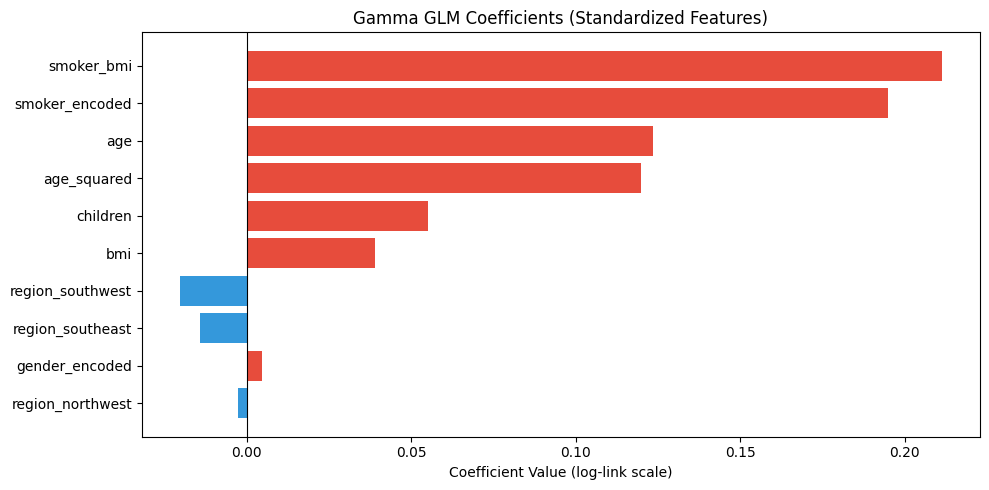

In [47]:
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("Feature Coefficients (sorted by absolute value):\n")
for _, row in coef_df.iterrows():
    print(f"  {row['Feature']:25s} : {row['Coefficient']:>12.4f}")

plt.figure(figsize=(10, 5))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.xlabel('Coefficient Value (log-link scale)')
plt.title('Gamma GLM Coefficients (Standardized Features)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Deviance Residual Diagnostics

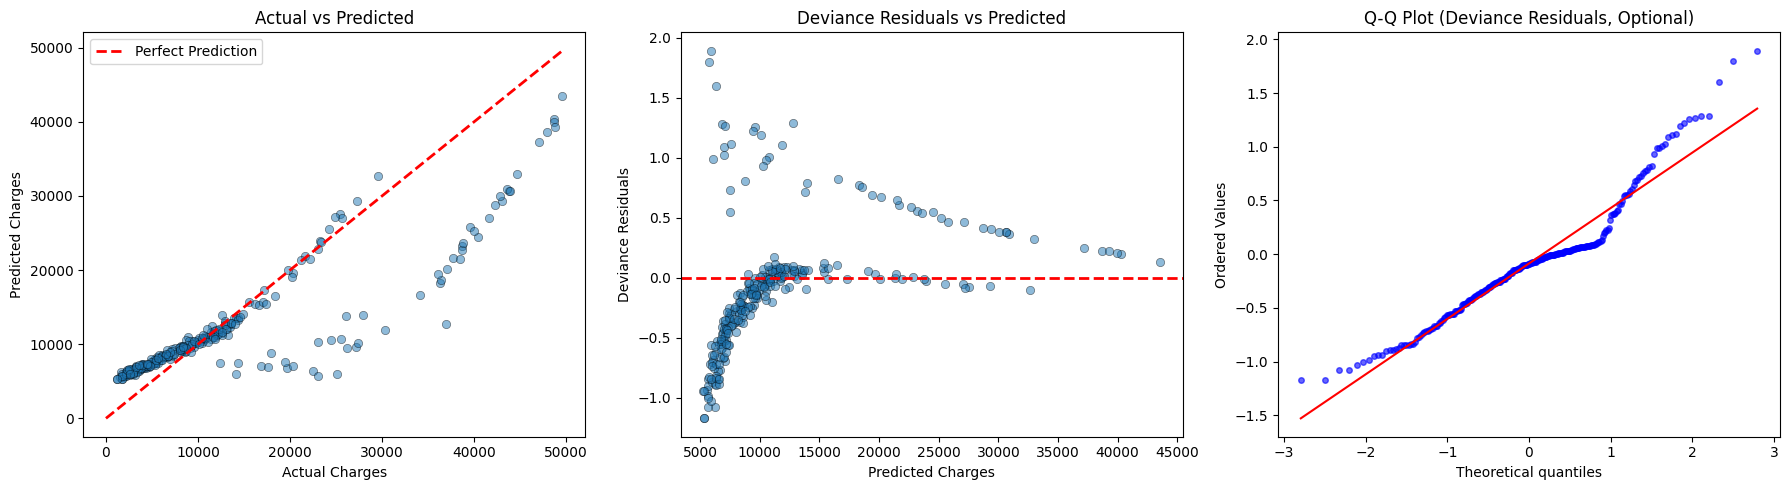

In [48]:
import scipy.stats as scipy_stats

# Raw residual (for quick direction check)
residuals = y_test - y_pred_test

# Deviance residual approximation for Gamma log-link
# sign(y - mu) * sqrt(2 * [ (y-mu)/mu - log(y/mu) ])
y_true = np.asarray(y_test, dtype=float)
y_hat = np.clip(np.asarray(y_pred_test, dtype=float), 1e-9, None)
term = (y_true - y_hat) / y_hat - np.log(y_true / y_hat)
deviance_residuals = np.sign(y_true - y_hat) * np.sqrt(np.maximum(2.0 * term, 0.0))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, y_pred_test, alpha=0.5, edgecolors='black', linewidths=0.5)
max_val = max(y_test.max(), y_pred_test.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Charges')
axes[0].set_ylabel('Predicted Charges')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

axes[1].scatter(y_pred_test, deviance_residuals, alpha=0.5, edgecolors='black', linewidths=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Charges')
axes[1].set_ylabel('Deviance Residuals')
axes[1].set_title('Deviance Residuals vs Predicted')

scipy_stats.probplot(deviance_residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (Deviance Residuals, Optional)')
axes[2].get_lines()[0].set(markersize=4, alpha=0.6)

plt.tight_layout()
plt.show()

## 7. Feature Ablation with Cross-Validation (Train Only)

In [49]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, mean_gamma_deviance

# Define feature sets for ablation
base_features = [
    'age', 'bmi', 'children', 'gender_encoded',
    'smoker_encoded', 'region_northwest', 'region_southeast', 'region_southwest'
]

feature_sets = {
    'base': base_features,
    'base + smoker_bmi': base_features + ['smoker_bmi'],
    'base + age_squared': base_features + ['age_squared'],
    'base + both': base_features + ['smoker_bmi', 'age_squared']
}

# Model selection must use training split only (no holdout leakage)
train_idx = X_train.index
train_df = data_df.loc[train_idx].copy()
X_modelsel = train_df
y_modelsel = train_df['charges']

# For sklearn scorer convention, negate deviance so higher is better internally
# and convert back to positive in the final table.
gamma_dev_scorer = make_scorer(mean_gamma_deviance, greater_is_better=False)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_rows = []
for feature_set_name, cols in feature_sets.items():
    X_cv = X_modelsel[cols]

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', GammaRegressor(alpha=0.1, max_iter=1000))
    ])

    scores = cross_validate(
        pipe,
        X_cv,
        y_modelsel,
        cv=cv,
        scoring={
            'gamma_dev': gamma_dev_scorer,
            'mae': 'neg_mean_absolute_error',
            'rmse': 'neg_root_mean_squared_error',
        },
        n_jobs=1
    )

    cv_rows.append({
        'feature_set': feature_set_name,
        'gamma_deviance_cv_mean': -scores['test_gamma_dev'].mean(),
        'mae_cv_mean': -scores['test_mae'].mean(),
        'rmse_cv_mean': -scores['test_rmse'].mean(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values('gamma_deviance_cv_mean')

formatted_cv_results = cv_results.copy()
formatted_cv_results['gamma_deviance_cv_mean'] = formatted_cv_results['gamma_deviance_cv_mean'].map(lambda x: f"{x:,.4f}")
formatted_cv_results['mae_cv_mean'] = formatted_cv_results['mae_cv_mean'].map(lambda x: f"{x:,.2f}")
formatted_cv_results['rmse_cv_mean'] = formatted_cv_results['rmse_cv_mean'].map(lambda x: f"{x:,.2f}")

print('Feature Ablation Results (5-Fold CV, Train Only):\n')
print(formatted_cv_results.to_string(index=False))

Feature Ablation Results (5-Fold CV, Train Only):

       feature_set gamma_deviance_cv_mean mae_cv_mean rmse_cv_mean
       base + both                 0.2502    4,059.58     7,325.36
 base + smoker_bmi                 0.2507    3,996.34     6,953.50
base + age_squared                 0.2647    4,268.24     7,301.11
              base                 0.2653    4,188.58     7,026.59


## 8. Alpha Tuning (GammaRegressor, Train Only)

We tune `alpha` using 5-fold cross-validation on the selected feature set from section 7, using training split only. The holdout test set is used once at the end for final evaluation.

In [50]:
# Alpha tuning on selected feature set (train split only)
alpha_grid = [0.001, 0.01, 0.1, 1.0, 10.0]
selected_feature_set_name = cv_results.iloc[0]['feature_set']
selected_features = feature_sets[selected_feature_set_name]

X_tune = X_modelsel[selected_features]
y_tune = y_modelsel

tuning_rows = []
for alpha in alpha_grid:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', GammaRegressor(alpha=alpha, max_iter=1000))
    ])

    scores = cross_validate(
        pipe,
        X_tune,
        y_tune,
        cv=cv,
        scoring={
            'gamma_dev': gamma_dev_scorer,
            'mae': 'neg_mean_absolute_error',
            'rmse': 'neg_root_mean_squared_error',
        },
        n_jobs=1
    )

    tuning_rows.append({
        'alpha': alpha,
        'gamma_deviance_cv_mean': -scores['test_gamma_dev'].mean(),
        'mae_cv_mean': -scores['test_mae'].mean(),
        'rmse_cv_mean': -scores['test_rmse'].mean(),
    })

alpha_results = pd.DataFrame(tuning_rows).sort_values('gamma_deviance_cv_mean')

formatted_alpha_results = alpha_results.copy()
formatted_alpha_results['gamma_deviance_cv_mean'] = formatted_alpha_results['gamma_deviance_cv_mean'].map(lambda x: f"{x:,.4f}")
formatted_alpha_results['mae_cv_mean'] = formatted_alpha_results['mae_cv_mean'].map(lambda x: f"{x:,.2f}")
formatted_alpha_results['rmse_cv_mean'] = formatted_alpha_results['rmse_cv_mean'].map(lambda x: f"{x:,.2f}")

print(f"Alpha Tuning Results (5-Fold CV, Train Only) - Feature Set: {selected_feature_set_name}\n")
print(formatted_alpha_results.to_string(index=False))

best_by_dev = alpha_results.loc[alpha_results['gamma_deviance_cv_mean'].idxmin()]
best_by_rmse = alpha_results.loc[alpha_results['rmse_cv_mean'].idxmin()]
best_alpha = float(best_by_dev['alpha'])

# Keep feature name source consistent for downstream interpretation cells
feature_cols = selected_features

print('\nBest alpha by Gamma Deviance :', best_by_dev['alpha'])
print('Best alpha by RMSE          :', best_by_rmse['alpha'])

# Final holdout evaluation (test set is used once, after model selection)
X_train_final = data_df.loc[X_train.index, selected_features]
X_test_final = data_df.loc[X_test.index, selected_features]

final_scaler = StandardScaler()
X_train_final_scaled = final_scaler.fit_transform(X_train_final)
X_test_final_scaled = final_scaler.transform(X_test_final)

model = GammaRegressor(alpha=best_alpha, max_iter=1000)
model.fit(X_train_final_scaled, y_train)

y_pred_train = model.predict(X_train_final_scaled)
y_pred_test = model.predict(X_test_final_scaled)

gamma_dev_train = mean_gamma_deviance(y_train, y_pred_train)
gamma_dev_test = mean_gamma_deviance(y_test, y_pred_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

# Optional metric
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f"\nFinal holdout evaluation with tuned alpha={best_alpha:g}")
print(f"Gamma Deviance Train/Test: {gamma_dev_train:,.4f} / {gamma_dev_test:,.4f}")
print(f"RMSE           Train/Test: {rmse_train:,.2f} / {rmse_test:,.2f}")
print(f"MAE            Train/Test: {mae_train:,.2f} / {mae_test:,.2f}")
print(f"R2 (optional)  Train/Test: {r2_train:.4f} / {r2_test:.4f}")

Alpha Tuning Results (5-Fold CV, Train Only) - Feature Set: base + both

 alpha gamma_deviance_cv_mean mae_cv_mean rmse_cv_mean
 0.001                 0.2470    4,498.13     8,822.71
 0.010                 0.2471    4,395.91     8,460.86
 0.100                 0.2502    4,059.58     7,325.36
 1.000                 0.3156    4,309.92     6,966.54
10.000                 0.6166    7,617.21    10,646.39

Best alpha by Gamma Deviance : 0.001
Best alpha by RMSE          : 1.0

Final holdout evaluation with tuned alpha=0.001
Gamma Deviance Train/Test: 0.2334 / 0.2683
RMSE           Train/Test: 8,638.08 / 9,413.09
MAE            Train/Test: 4,378.72 / 4,689.65
R2 (optional)  Train/Test: 0.4855 / 0.3625
